<a href="https://colab.research.google.com/github/sadhub10/SIC-2025-Aulas-Pa09-y-Pa10/blob/main/Clase%201%20-%20IA%20-%20Capitulo%207%20-%20Unidad%203%20y%204%20-%20del%2017%20al%2018/11/25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🚀 Estructura de Clase: PLN**

### Bloque I: Fundamentos del Modelo Lingüístico y n-Grams (20 min)

### 🧠 ¿Qué es un Modelo Lingüístico?
Un Modelo Lingüístico es esencialmente un modelo predictivo que tiene dos funciones principales:

* Asignar una Probabilidad: Calcula la probabilidad de que una secuencia de elementos del lenguaje (palabras, letras, frases) aparezca en el mundo real.

Ejemplo: Un ML evalúa la frase "El perro ladró al gato" como mucho más probable que "Gato al ladró perro El".

* Predecir o Generar el Siguiente Componente: Basándose en una secuencia de palabras dada, predice cuál es la palabra o combinación de palabras más probable a continuación.

Ejemplo: Si el modelo ve "El cielo está...", predecirá una alta probabilidad para "nublado" o "azul".

### 💡 Analogía
Piensa en un ML como un corrector de gramática y sentido común a escala masiva . Ha "leído" tanto texto que puede distinguir entre lo que suena natural y lo que no, basándose en la frecuencia y el contexto.

### Tipos de modelos lingüísticos
Los ML se dividen históricamente en dos categorías principales:

1. Modelo Lingüístico Estadístico (SLM)
Se basan en la frecuencia y las matemáticas simples para calcular probabilidades.

* n-Grams: Es el modelo estadístico más conocido.

Se enfoca en secuencias consecutivas de $n$ elementos (generalmente palabras). Un Bigrama ($n=2$) solo mira las dos palabras anteriores para predecir la siguiente.

Limitación: Sufre del problema de la "dispersión de datos" o sparsity . Si una secuencia nunca ha aparecido en el texto de entrenamiento, su probabilidad es cero, incluso si es lógicamente posible.

2. Modelo Lingüístico de Aprendizaje Profundo

Utilizan Redes Neuronales Artificiales (RNA) para aprender representaciones del lenguaje. Son los modelos dominantes hoy en día (como GPT, BERT, etc.).

Ventaja: Superan las limitaciones de los n-Grams al capturar dependencias a largo plazo y entender el contexto semántico , no solo la frecuencia.

### Aplicaciones Clave
Los ML son la base de numerosas tareas de PLN:

Generación de Documentos: Creación de texto coherente, como chatbots o herramientas de escritura automática.

Traducción Automática: Evalúan qué traducción es más probable y natural en el idioma de destino.

Corrección Ortográfica y Autocompletada: Predicen la palabra que el usuario está tratando de escribir o sugerir correcciones.

### 1. Código:  Extracción de n-Grams (Ejercicio #0509)

En este código muestramos cómo generar n-Grams (secuencias de $n$ palabras) a partir de una frase, fundamental para entender los Modelos Lingüísticos Estadísticos. Usamos la librería nltk.

In [7]:
import nltk
from nltk.util import ngrams

# 1. DESCARGA DE RECURSOS NECESARIOS
# Este paso es crucial, especialmente 'punkt', para que word_tokenize funcione.
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    print("Descargando recurso 'punkt' de NLTK...")
    nltk.download('punkt')

# Descargar el recurso 'punkt_tab' para el idioma español si no está disponible
try:
    nltk.data.find('tokenizers/punkt_tab/spanish/')
except LookupError:
    print("Descargando recurso 'punkt_tab' para español de NLTK...")
    nltk.download('punkt_tab')

# 1. Definir una frase de ejemplo
texto_ejemplo = "El procesamiento del lenguaje natural es fascinante."

# 2. Tokenizar la frase en palabras
# Convertimos a minúsculas para un análisis de PLN estándar
palabras = nltk.word_tokenize(texto_ejemplo.lower(), language='spanish')

# El valor de n define el tamaño de la ventana o secuencia que estamos observando:

# 3. Generar Bigramas (n=2)
# Un Bigrama es una secuencia de 2 palabras consecutivas
bigramas = list(ngrams(palabras, 4))
print("--- Bigramas (n=2) ---")
print(bigramas)

# 4. Generar Trigramas (n=3)
# Un Trigrama es una secuencia de 3 palabras consecutivas
trigramas = list(ngrams(palabras, 5))
print("\n--- Trigramas (n=3) ---")
print(trigramas)

--- Bigramas (n=2) ---
[('el', 'procesamiento', 'del', 'lenguaje'), ('procesamiento', 'del', 'lenguaje', 'natural'), ('del', 'lenguaje', 'natural', 'es'), ('lenguaje', 'natural', 'es', 'fascinante'), ('natural', 'es', 'fascinante', '.')]

--- Trigramas (n=3) ---
[('el', 'procesamiento', 'del', 'lenguaje', 'natural'), ('procesamiento', 'del', 'lenguaje', 'natural', 'es'), ('del', 'lenguaje', 'natural', 'es', 'fascinante'), ('lenguaje', 'natural', 'es', 'fascinante', '.')]


JUAN VA PARA EL JUEGO DE PANAMA, A LA VICTORIA DE SU SELECCIÓN.

### Bloque II: Representación Vectorial del Texto (35 min)

En este bloque, el objetivo es convertir las palabras y documentos en números que el ordenador pueda procesar.

El modelo de representación Bag of Words (BOW) , o "Bolsa de Palabras" , es uno de los métodos más sencillos y fundamentales para convertir el texto en un formato numérico que los algoritmos de Machine Learning pueden procesar.

### 🛍️ Concepto de Bag of Words (BOW)
El modelo BOW trata un documento o una porción de texto como una colección o "bolsa" desordenada de palabras .

1. Ignora el Orden: La característica más definitoria de BOW es que prescinde totalmente del orden, la gramática y la estructura sintáctica de las palabras en el documento.

2. Se Enfoca en la Frecuencia: Lo único que le importa al modelo es qué palabras están presentes en el documento y cuántas veces aparece cada una.

### 💡 Analogía
Piensa en una bolsa de la compra: no importa en qué orden pusiste los artículos (leche, pan, huevos), solo importa que esos tres artículos (palabras) estén presentes y cuántas unidades tienes de cada uno.

### ¿Cómo funciona?
* El proceso para crear una representación BOW se resume en estos pasos:

* Creación del Vocabulario: Se analiza todo el conjunto de documentos (corpus) para crear un vocabulario único de todas las palabras que aparecen.

* Vectorización: Cada documento se convierte en un vector numérico . La longitud de este vector es igual al tamaño del vocabulario único.

* Conteo: Para cada documento, el valor de cada posición en el vector es la frecuencia de conteo de la palabra correspondiente en ese documento.

### Práctico
Documento 1: "El perro como hueso".

Documento 2: "El gato no viene".

Vocabulario Único: ["El", "perro", "come", "hueso", "gato", "no"]

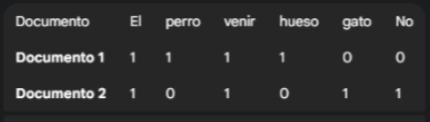

### Usos y Limitaciones
**✅ Usos Principales**

Clasificación de Textos: Es una característica básica y efectiva para clasificadores sencillos como Naïve Bayes o Regresión Logística .

Modelado de Temas (LDA): La mayoría de los modelos de Modelado de Temas utilizan el conteo de frecuencias (esencialmente BOW) como entrada .

Preprocesamiento: A menudo es el punto de partida para otros modelos de representación más avanzados como TF-IDF .

**❌ Limitaciones Importantes**

Pérdida de Contexto y Semántica: Al ignorar el orden, se pierde información crucial. Las frases "Juan no es feliz" y "Juan es feliz" podrían tener vectores BOW idénticos si ignoramos la palabra "no".

Alta DimensionalidaD (Sparsity): Si el vocabulario es muy grande (común en corpus reales), los vectores resultantes son enormes y están llenos de ceros, lo que se conoce como dispersión ( sparsity ) . Esto consume mucha memoria y ralentiza los cálculos.

No Maneja Sinónimos: Las palabras con el mismo significado (sinónimos), como "automóvil" y "coche", son tratadas como dos características totalmente distintas, ya que solo se basan en el conteo de palabras literales.

### 🐍 Código de ejemplo:
Implementación del Modelo Bag of Words
Usaremos CountVectorizerde scikit-learn, que es la herramienta que implementa el modelo BOW.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# 1. Definir un pequeño Corpus (conjunto de documentos)
corpus = [
    "El perro corre rápido.",
    "El gato duerme tranquilo.",
    "El gato y el perro juegan.",
    "Correr rápido es divertido."
]

# 2. Crear el Vectorizador CountVectorizer (Implementa BOW)
# Este objeto automáticamente:
# a) Crea el vocabulario único.
# b) Convierte el texto a minúsculas y tokeniza.
vectorizador_bow = CountVectorizer()

# 3. Ajustar y Transformar el corpus
# 'fit' aprende el vocabulario. 'transform' convierte el texto a la matriz de conteos.
matriz_bow = vectorizador_bow.fit_transform(corpus)

# 4. Obtener las características (el vocabulario único)
caracteristicas = vectorizador_bow.get_feature_names_out()

# 5. Crear un DataFrame para visualizar la Matriz Documento-Término (DTM)
df_bow = pd.DataFrame(matriz_bow.toarray(), columns=caracteristicas)

print("--- 1. Vocabulario Único (Características) ---")
print(caracteristicas)
print("-" * 40)

print("--- 2. Matriz Documento-Término (Representación BOW) ---")
print(df_bow)

--- 1. Vocabulario Único (Características) ---
['corre' 'correr' 'divertido' 'duerme' 'el' 'es' 'gato' 'juegan' 'perro'
 'rápido' 'tranquilo']
----------------------------------------
--- 2. Matriz Documento-Término (Representación BOW) ---
   corre  correr  divertido  duerme  el  es  gato  juegan  perro  rápido  \
0      1       0          0       0   1   0     0       0      1       1   
1      0       0          0       1   1   0     1       0      0       0   
2      0       0          0       0   2   0     1       1      1       0   
3      0       1          1       0   0   1     0       0      0       1   

   tranquilo  
0          0  
1          1  
2          0  
3          0  


### 🐍 Código: TF-IDF y Similitud del Coseno con Pandas (Ejercicio #0510)

En este código demuestramos cómo convertir texto en vectores numéricos usando TF-IDF y luego usar la Similitud del Coseno para medir la relación temática entre los documentos.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# 1. Corpus de documentos
corpus = [
    "El perro corre rápido en el parque.",      # Documento 1 (D1)
    "El gato duerme tranquilo en la casa.",     # Documento 2 (D2)
    "El algoritmo de procesamiento de texto.",   # Documento 3 (D3)
    "Un buen algoritmo es esencial para PLN."   # Documento 4 (D4)
]

# 2. Vectorización TF-IDF
vectorizador_tfidf = TfidfVectorizer()
matriz_tfidf = vectorizador_tfidf.fit_transform(corpus)

# 3. Calcular la Matriz de Similitud del Coseno
matriz_similitud = cosine_similarity(matriz_tfidf)

# --- Visualización Mejorada con Pandas ---

# 4. Etiquetas de los documentos
documentos = ['Doc 1 (Animal)', 'Doc 2 (Animal)', 'Doc 3 (Tecnología)', 'Doc 4 (Tecnología)']

# 5. Creación del DataFrame de la Matriz de Similitud
df_similitud = pd.DataFrame(
    matriz_similitud.round(4), # Redondeado a 4 decimales
    index=documentos,          # Filas
    columns=documentos         # Columnas
)

print("--- 1. Matriz de Similitud del Coseno (Documento vs Documento) ---")
print("Valores cercanos a 1 indican alta similitud temática.")
print("\n")
print(df_similitud)
print("-" * 70)

# Ejemplo específico
print(f"\nSimilitud (Doc 1 vs Doc 3): {matriz_similitud[0][2]:.4f}")
print(f"Similitud (Doc 3 vs Doc 4): {matriz_similitud[2][3]:.4f}")

--- 1. Matriz de Similitud del Coseno (Documento vs Documento) ---
Valores cercanos a 1 indican alta similitud temática.


                    Doc 1 (Animal)  Doc 2 (Animal)  Doc 3 (Tecnología)  \
Doc 1 (Animal)              1.0000          0.2340              0.1229   
Doc 2 (Animal)              0.2340          1.0000              0.0626   
Doc 3 (Tecnología)          0.1229          0.0626              1.0000   
Doc 4 (Tecnología)          0.0000          0.0000              0.0911   

                    Doc 4 (Tecnología)  
Doc 1 (Animal)                  0.0000  
Doc 2 (Animal)                  0.0000  
Doc 3 (Tecnología)              0.0911  
Doc 4 (Tecnología)              1.0000  
----------------------------------------------------------------------

Similitud (Doc 1 vs Doc 3): 0.1229
Similitud (Doc 3 vs Doc 4): 0.0911


### Bloque III: Aplicaciones Clásicas de PLN (35 min)

El Análisis de Clasificación es una de las Aplicaciones Clásicas y más importantes del PLN en la Minería de Textos. Consiste en asignar una etiqueta o categoría predefinida a un documento de texto.

El Clasificador Naïve Bayes es, históricamente, el algoritmo más común y eficaz para esta tarea, especialmente cuando se combina con la representación TF-IDF (Frecuencia de Término - Frecuencia Inversa de Documento) .

### 🎯 Análisis de Clasificación en PLN

La clasificación de texto busca responder a preguntas como:

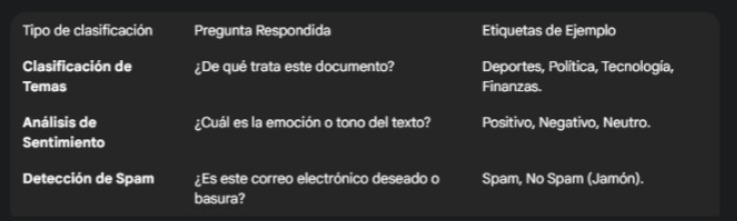

### El Proceso Clásico de Clasificación
Un análisis de clasificación de texto con un modelo estadístico sigue tres pasos principales:

* Representación del Texto: El texto se transforma en un formato numérico. La representación más común para este tipo de modelos es la matriz de TF-IDF , ya que el clasificador necesita pesos para distinguir las palabras importantes.

* Entrenamiento del Modelo: El modelo (por ejemplo, Naïve Bayes) aprende a asociar los vectores numéricos de los documentos con sus etiquetas conocidas.

* predicción: El modelo toma un nuevo documento (que no conoce), lo vectoriza y predice la etiqueta más probable.

### 🐍 Código de ejemplo:

Clasificación con Naïve Bayes y TF-IDF
Este código utiliza la representación TF-IDF para entrenar un clasificador Naïve Bayes en una tarea de clasificación de temas simple.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report

# 1. Datos de Entrenamiento (Corpus y Etiquetas)
textos_entrenamiento = [
    "La bolsa de valores subió tras el anuncio económico del gobierno.", # Finanzas a Economia
    "El nuevo jugador estrella del fútbol se lesionó la rodilla.",      # Deportes
    "El partido político votó en contra de la reforma fiscal.",         # Política
    "Comprar y vender acciones requiere análisis de mercado.",          # Finanzas
    "El entrenador prepara al equipo para la próxima liga.",           # Deportes
    "El congreso aprobó la nueva ley de seguridad social."              # Política
]
etiquetas_entrenamiento = ['Finanzas', 'Deportes', 'Política', 'Finanzas', 'Deportes', 'Política']

# 2. Creación del Pipeline
# Un pipeline simplifica el proceso:
# Paso 1: Transforma el texto a vectores TF-IDF.
# Paso 2: Entrena el clasificador Naive Bayes con esos vectores.
modelo_nb = make_pipeline(TfidfVectorizer(), MultinomialNB())

# 3. Entrenamiento del Modelo
modelo_nb.fit(textos_entrenamiento, etiquetas_entrenamiento)

# 4. Datos de Prueba (Nuevos documentos para clasificar)
nuevos_textos = [
    "El mercado de divisas está volátil hoy.", # Esperado: Finanzas
    "El presidente dio un discurso en la capital.",  # Esperado: Política
    "El equipo de baloncesto ganó el campeonato."  # Esperado: Deportes
]

# 5. Predicción
predicciones = modelo_nb.predict(nuevos_textos)

print("--- Resultados de la Clasificación Naïve Bayes ---")
for texto, prediccion in zip(nuevos_textos, predicciones):
    print(f"Texto: '{texto[:30]}...' -> Clasificación: {prediccion}")

--- Resultados de la Clasificación Naïve Bayes ---
Texto: 'El mercado de divisas está vol...' -> Clasificación: Finanzas
Texto: 'El presidente dio un discurso ...' -> Clasificación: Política
Texto: 'El equipo de baloncesto ganó e...' -> Clasificación: Deportes


### 🔎 ¿Qué es LDA en el contexto de la Semántica Latente?

LDA ( Latent Dirichlet Allocation ) es un modelo de temas que se clasifica como un modelo generativo probabilístico . Aunque cumple el mismo objetivo que el LSA (descubrir temas), opera bajo un principio matemático y filosófico completamente diferente:

1. Modelo Generativo (Asunción de LDA)

LDA postula que cada documento y cada tema tienen una estructura probabilística subyacente:

* Documento como Mezcla de Temas: Un documento es una mezcla de diversos temas. Por ejemplo, un artículo sobre "economía" podría tener un 70% del Tema 1 (Finanzas) y un 30% del Tema 2 (Política).

+ Tema como Mezcla de Palabras: Un tema es una mezcla de palabras. Por ejemplo, el Tema 1 (Finanzas) podría tener una alta probabilidad para palabras como "mercado", "acciones" y "banco".

El trabajo de LDA es invertir el proceso : dado el corpus de documentos, intenta inferir (o descubrir ) cuáles son las distribuciones de temas por documento y cuáles son las distribuciones de palabras por tema.



2. Base Matemática: Distribución Dirichlet
LDA utiliza la Distribución de Dirichlet para modelar las mezclas de temas y palabras. Esta distribución es adecuada porque asegura que las probabilidades de los temas en un documento (y las probabilidades de las palabras en un tema) sumen exactamente 1, manteniendo la cohesión.

### 🆚 Diferencias Clave con LSA (Análisis Semántico Latente)

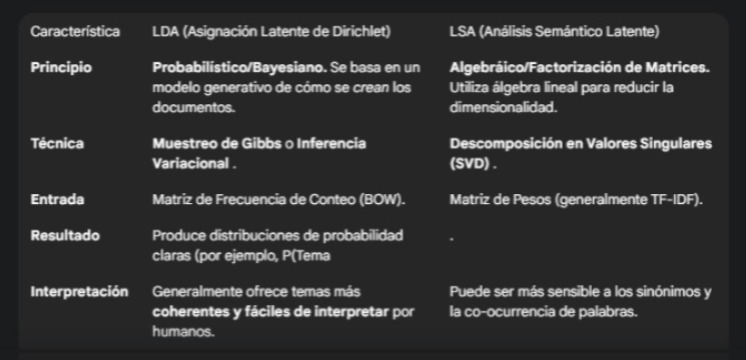

Si bien LSA es una técnica de reducción de dimensionalidad que descubre la semántica a través de la co-ocurrencia de palabras (álgebra), LDA es un modelo estadístico que descubre la semántica asumiendo un proceso de generación probabilística subyacente. Ambos te dicen qué temas hay, pero LDA es el estándar de oro por la claridad y la base probabilística de sus resultados.

### 3. Modelado de Temas (LDA) (Ejercicio #0513)
Este código utiliza el modelo Latent Dirichlet Allocation (LDA) para inferir temas ocultos de un conjunto de documentos.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords') # Asegurarse de que las stopwords están descargadas

# 1. Corpus de ejemplo (diferentes temas: Ciencia, Política, Cocina)
documentos = [
    "El telescopio James Webb capturó nuevas imágenes del universo profundo.",
    "El congreso aprobó una ley para regular el precio de los alimentos básicos.",
    "Para preparar el pastel se necesita harina, huevos, azúcar y batir la mezcla.",
    "Los científicos descubrieron un exoplaneta con atmósfera similar a la Tierra.",
    "El presidente dio un discurso sobre la economía y las elecciones futuras.",
    "La receta de pollo asado requiere especias, limón y un horno caliente."
]

# 2. Vectorización (Bag of Words) - LDA prefiere conteos brutos
# Usar stopwords de NLTK para español
vectorizador = CountVectorizer(stop_words=stopwords.words('spanish'))
data_vectorizada = vectorizador.fit_transform(documentos)

# 3. Aplicar LDA
n_temas = 3 # Queremos encontrar 3 temas
lda = LatentDirichletAllocation(n_components=n_temas, random_state=42)
lda.fit(data_vectorizada)

# 4. Función para imprimir las palabras clave de cada tema
n_palabras_top = 5
palabras = vectorizador.get_feature_names_out()

print("--- Resultados del Modelado de Temas (LDA) ---")
for indice_tema, top_palabras_tema in enumerate(lda.components_):
    palabras_clave = [palabras[i] for i in top_palabras_tema.argsort()[:-n_palabras_top - 1:-1]]
    print(f"Tema #{indice_tema + 1}: {', '.join(palabras_clave)}")

--- Resultados del Modelado de Temas (LDA) ---
Tema #1: webb, universo, telescopio, profundo, imágenes
Tema #2: regular, ley, precio, congreso, aprobó
Tema #3: preparar, necesita, pastel, huevos, azúcar


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Bloque IV: Procesamiento del Lenguaje Natural con Keras (30 min)

### 🧠 ¿Qué son los Word Embeddings?

Un Word Embedding es una representación vectorial densa de una palabra. En términos sencillos, es un conjunto de números (un vector) que codifica el significado semántico y sintáctico de esa palabra en un espacio multidimensional.

💡 Analogía Clave: El "Barrio" de los Significados
Imagina que cada palabra vive en una ciudad con millas de dimensiones.

* Si dos palabras son semánticamente similares (por ejemplo, "perro" y "gato"), sus vectores (sus "direcciones" en la ciudad) estarán muy cerca uno del otro.

* Si dos palabras son diferentes ("perro" y "cuchara"), sus vectores estarán muy lejos .

El vector no es aleatorio; sus valores se aprenden durante el entrenamiento, generalmente de forma no supervisada, analizando el contexto en el que aparece la palabra en un corpus masivo.

### 🆚 Ventaja Clave sobre Representaciones Clásicas

Los Word Embeddings resuelven las principales limitaciones de los modelos clásicos (como BOW y TF-IDF):

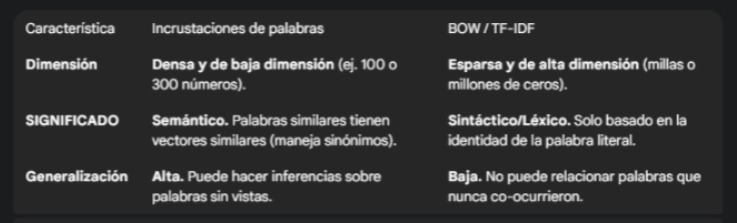

### Arquitectura con KERAS

La Arquitectura de PLN con Keras se refiere al diseño de modelos de Redes Neuronales Profundas para procesar texto, combinando capas especializadas para aprovechar las ventajas de los Word Embeddings y el manejo de secuencias.

Basado en tu presentación (Unidad 4), la arquitectura más poderosa para tareas como la clasificación de documentos es el Modelo Híbrido Convolucional-Recurrente .

### 🧱 Componentes de la Arquitectura con Keras

La arquitectura de Keras se construye de forma secuencial, donde la salida de una capa se convierte en la entrada de la siguiente.


1. Capa Embedding(Representación)
* Propósito: Esta es la capa de entrada. Convierte la secuencia de índices enteros de las palabras en vectores densos de Word Embedding .

* Función: Transforma la representación simbólica de las palabras en un espacio vectorial donde las distancias reflejan la similitud semántica.

* : mi_modelo.add(Embedding(n_palabras, n_entrada))

2. Capa Conv1D(Extracción de Características Locales)

* Propósito: Detectar patrones locales y combinaciones de palabras importantes (similares a los n-Grams, pero de forma dinámica).

* Función: Una "ventana" (kernel) se desliza sobre los vectores de Embedding para identificar características relevantes en frases cortas.

* : my_model.add(Conv1D(filters=n_filters, kernel_size=k_size, activation='relu'))

3. Capa MaxPool1D(Reducción de Dimensionalidad)

* Propósito: Reducir la dimensionalidad y el número de parámetros de la salida de la capa Conv1D.

* Función: Tomar el valor máximo de cada característica detectada en una ventana, manteniendo solo la información más relevante y haciendo el modelo más eficiente y robusto a pequeñas variaciones.

* : mi_modelo.add(MaxPool1D(pool_size=2))

4. Capa LSTM(Memoria Secuencial)

* Propósito: Capturar la dependencia de largo plazo y el contexto secuencial del documento.

* Función: Las Redes LSTM (Long Short-Term Memory) recuerdan información clave a lo largo de largas secuencias de texto, vital para entender el sentido completo de la oración o párrafo. Es esencial para manejar la naturaleza secuencial del lenguaje.

* : my_model.add(LSTM(units=n_neuronas, activation='tanh'))

5. Capa Dropout(Regularización)
* Propósito: Prevenir el overfitting (sobreajuste).

* Función: Desactiva aleatoriamente un porcentaje de neuronas durante el entrenamiento. Esto obliga al modelo a no depender de una sola ruta de características ya aprender representaciones más robustas.

* : my_model.add(Dropout(rate=hold_prob))

6. Capa Dense(Clasificación Final)

* Propósito: Generar la salida final (la predicción).

* Función: Es una capa completamente conectada que toma las características finales y las mapea al número de clases deseadas.

Para clasificación binaria (ej., Positivo/Negativo): Una neurona con activación sigmoid.

Para clasificación multiclase (ej., 10 categorías):$N$neuronas con activación softmax.

* : mi_modelo.add(Dense(1, activation='sigmoide'))

### 4. Arquitectura de Deep Learning con Keras (Referencia #0514 - #0516)

Este es el modelo híbrido avanzado que se construye con Keras para la clasificación de texto (por ejemplo, clasificación de sentimientos o documentos), combinando capas convolucionales y recurrentes.

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM, Embedding, Conv1D, MaxPool1D, Dropout, Input

# --- Parámetros de Configuración ---
n_palabras = 20000    # Tamaño del vocabulario
n_entrada = 100       # Dimensión del vector de Word Embedding
longitud_secuencia = 50   # Longitud máxima del texto de entrada
n_filters = 128       # Número de filtros Conv1D
k_size = 5            # Tamaño del kernel (ventana) Conv1D
n_neuronas_lstm = 64  # Número de neuronas en la capa LSTM
hold_prob = 0.5       # Tasa de Dropout para regularización

# 1. Inicializar el modelo secuencial
mi_modelo = Sequential()

# 1.1 Añadir la capa de entrada explícita (Keras 3.0 best practice)
mi_modelo.add(Input(shape=(longitud_secuencia,), name='Capa_Input'))

# --- COMENTARIO PARA ESTUDIANTES 🤓 ---
# **ESTRUCTURA DEL MODELO CNN-LSTM:**
# Esta arquitectura combina la capacidad de la CNN (Conv1D) para encontrar **patrones locales** (como n-gramas)
# con la habilidad de la LSTM para capturar **dependencias de largo plazo** en el texto.
#
# **¡CLAVE!** Para que Keras pueda calcular los millones de parámetros, debemos especificar la
# **longitud máxima de la secuencia** (`input_length`) en la primera capa (Embedding).
# Sin este dato, el resumen del modelo muestra '0 (unbuilt)'.

# 2. Capa de Incrustación (Embedding)
# En Keras 3.0, el primer argumento es 'num_embeddings' (antes 'input_dim')
# y 'input_shape' no se pasa si ya hay una capa Input explícita.
mi_modelo.add(Embedding(
    n_palabras,  # Pasa el tamaño del vocabulario como primer argumento posicional
    output_dim=n_entrada,
    name='Capa_Embedding'
))

# 3. Capa Convolucional 1D (Conv1D)
mi_modelo.add(Conv1D(
    filters=n_filters,
    kernel_size=k_size,
    activation='relu',
    name='Capa_Conv1D'
))

# 4. Capa de Max Pooling 1D
mi_modelo.add(MaxPool1D(
    pool_size=2,
    name='Capa_MaxPool1D'
))

# 5. Capa LSTM
mi_modelo.add(LSTM(
    units=n_neuronas_lstm,
    name='Capa_LSTM'
))

# 6. Capa de Dropout
mi_modelo.add(Dropout(
    rate=hold_prob,
    name='Capa_Dropout'
))

# 7. Capa Densa (Salida) para clasificación binaria
mi_modelo.add(Dense(
    1,
    activation='sigmoid',
    name='Capa_Salida'
))

# 8. Muestra el resumen del modelo y la cantidad de parámetros
print("\n--- Resumen de la Arquitectura de Keras ---")
mi_modelo.summary()


--- Resumen de la Arquitectura de Keras ---


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Capa_Embedding (Embedding)      │ (None, 50, 100)        │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Conv1D (Conv1D)            │ (None, 46, 128)        │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_MaxPool1D (MaxPooling1D)   │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_LSTM (LSTM)                │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Dropout (Dropout)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Salida (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,113,601 (8.06 MB)

 Trainable params: 2,113,601 (8.06 MB)

 Non-trainable params: 0 (0.00 B)

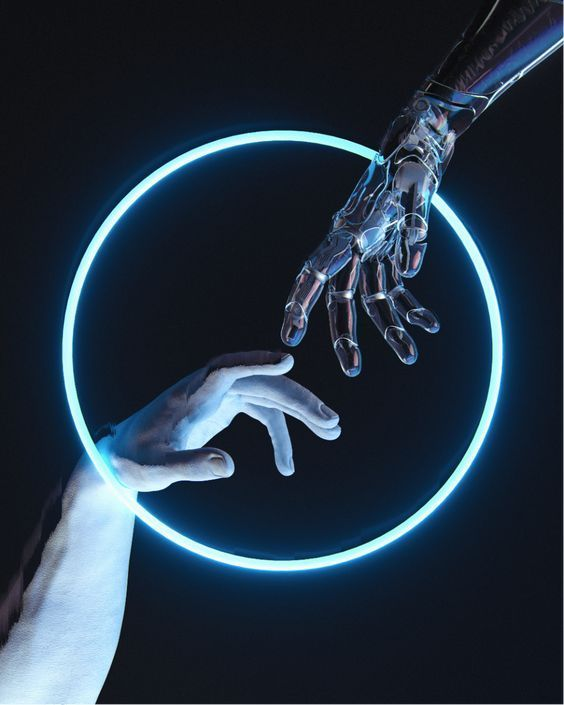

# `"Hemos aprendido que la minería de textos va más allá del conteo de palabras; es un viaje desde la frecuencia estadística (n-Grams y TF-IDF) hasta la captura del significado profundo (Word Embeddings y Keras), transformando el lenguaje humano en vectores inteligentes listos para construir el futuro de la IA."`

# `FIN`